In [10]:
pwd

'/global/u2/j/jzweifel/jupyterhub/ML/regression_techniques'

### <span style= "color:purple"> Imports

In [1]:
# Third-party imports
import numpy as np
import xarray as xr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

### <span style= "color:purple"> Loading data for ensemble member 01

In [2]:
# Target Data
# Contains radiative effects from 60 ensemble members
combined_radiative_effects = xr.open_dataset('/global/cfs/cdirs/m4997/Sagar_ensembles/radiative_effects/radiative_effects_60samples_12months.nc')

# Parent ds containing possible predictors from a single ensemble member
# lat: 192 lon: 288 lev: 32 ilev: 33 time: 12 nbnd: 2
full_ensemble_01 = xr.open_dataset('/global/cfs/cdirs/m4997/Sagar_ensembles/ncrct_F2000climo_18months_CESM2.2.2_PBNudged_Scaled_0.1_h1_2001.nc')

# Mask for North Atlantic Ocean aligned with CESM coordinates
NAO_mask = xr.open_dataarray('/global/homes/j/jzweifel/masks/NAO_mask_192x288.nc').assign_coords(lat=combined_radiative_effects.lat, lon=combined_radiative_effects.lon)

### <span style= "color:purple"> Organizing Features and Target Data for Linear Regression

In [3]:
# Step 1: Collect predictor variables and stack along a new "feature" dim
var_list = ['so4_a1', 'so4_a2', 'so4_a3', 'so4_c1', 'so4_c2', 'so4_c3']
all_vars = [full_ensemble_01[var].where(NAO_mask) for var in var_list]
X_concat = xr.concat(all_vars, dim="feature").assign_coords(feature=var_list)

# Step 2: Flatten (time,lat,lon) into "sample" dimension
X_stacked = X_concat.stack(sample=("time","lat","lon")).stack(full_feature=("feature","lev")).transpose("sample","full_feature")

# Step 3: Target variable (same stacking for alignment)
y = combined_radiative_effects["direct_radiative_effect_sulfate"].sel(sample=0).where(NAO_mask).stack(sample=("time","lat","lon"))

# Step 4: Drop NaNs together
X_stacked, y = xr.align(X_stacked, y, join="inner")

# # Step 5: Convert to NumPy
X_clean = X_stacked.values
y_clean = y.values

# Drop rows with NaNs
mask = ~np.isnan(X_clean).any(axis=1) & ~np.isnan(y_clean)
X_clean = X_clean[mask]
y_clean = y_clean[mask]

# Step 6: Fit regression
model = LinearRegression()
model.fit(X_clean, y_clean)
y_pred = model.predict(X_clean)

print("R² score:", r2_score(y_clean, y_pred))

R² score: 0.9695272165401385


### <span style= "color:purple"> Plotting Predictions vs Target

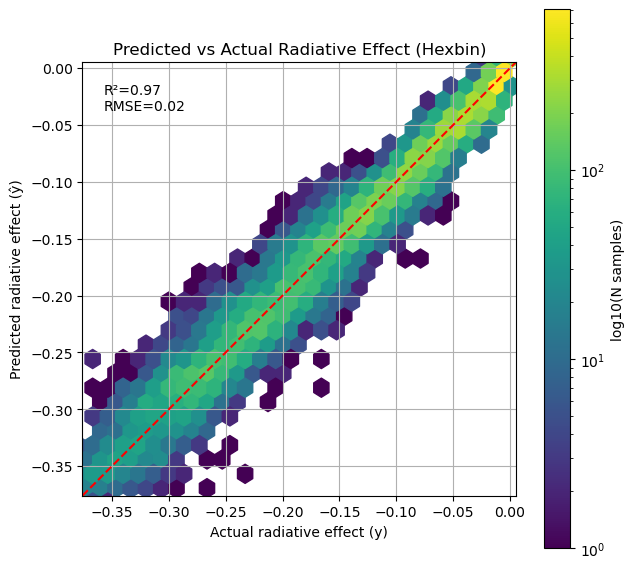

In [8]:
# Compute metrics first
r2_val = r2_score(y_clean, y_pred)
rmse_val = np.sqrt(mean_squared_error(y_clean, y_pred))

plt.figure(figsize=(7,7))
hb = plt.hexbin(y_clean, y_pred, gridsize=60, cmap="viridis", bins="log")
plt.colorbar(hb, label="log10(N samples)")

# 1:1 line and limits
lims = np.percentile(np.concatenate([y_clean, y_pred]), [1, 99])
plt.plot(lims, lims, 'r--', lw=1.5)
plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect('equal', adjustable='box')

plt.grid()
plt.xlabel("Actual radiative effect (y)")
plt.ylabel("Predicted radiative effect (ŷ)")
plt.title("Predicted vs Actual Radiative Effect (Hexbin)")

# ✅ Use the *values*, not the function names
plt.text(0.05, 0.95, f"R²={r2_val:.2f}\nRMSE={rmse_val:.2f}", transform=plt.gca().transAxes, ha="left", va="top", fontsize=10)

plt.show()

### <span style= "color:purple"> Plotting Predictions and Target in Space

In [5]:
# Original field with NaNs applied
y_field = combined_radiative_effects.sel(sample=0)["direct_radiative_effect_sulfate"].where(NAO_mask)

# Start from this shape, then fill valid entries
y_pred_xr = xr.full_like(y_field, np.nan)

# Stack to 1D
stacked = y_pred_xr.stack(sample=("time", "lat", "lon"))

# Fill only valid entries
stacked.values[mask] = y_pred

# Unstack back to 3D
y_pred_xr = stacked.unstack("sample")
y_pred_xr.name = "predicted_radiative_effect"

In [6]:
pred_slice = y_pred_xr.isel(time=0)
physical_slice = combined_radiative_effects["direct_radiative_effect_sulfate"].sel(sample=0).isel(time=0).where(NAO_mask)

# Align them (keeps only overlapping non-NaN coords)
pred_slice, physical_slice = xr.align(pred_slice, physical_slice, join="inner")

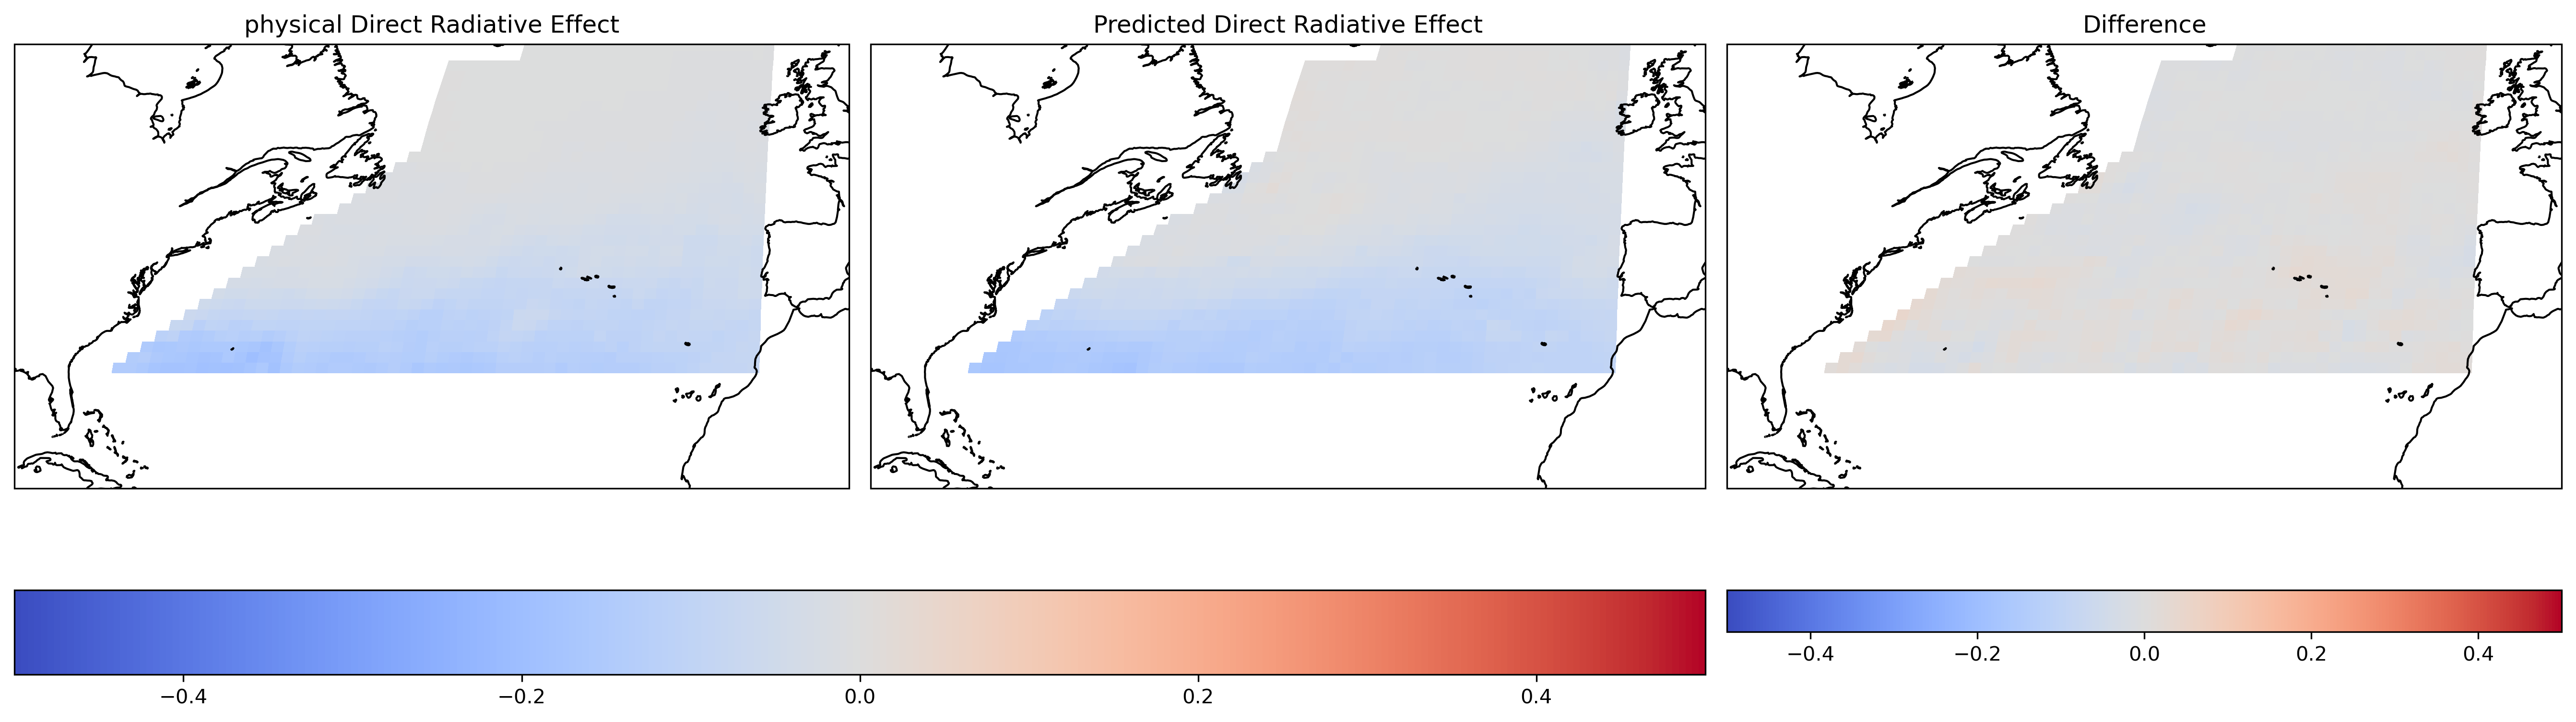

In [7]:
from matplotlib import pyplot as plt
import cartopy.feature as cfeature
import cartopy.crs as ccrs

fig, axs = plt.subplots(1, 3, subplot_kw={'projection': ccrs.Robinson()}, figsize=(18, 5), dpi=300)

lon = physical_slice.lon
lat = physical_slice.lat

fields = [physical_slice, pred_slice, physical_slice - pred_slice]
titles = ["physical Direct Radiative Effect", "Predicted Direct Radiative Effect", "Difference"]

# Plot each field
for i, field in enumerate(fields):
    m = axs[i].pcolormesh(
        lon, lat, field,
        cmap="coolwarm", vmin=-0.5, vmax=0.5,
        transform=ccrs.PlateCarree()
    )
    axs[i].add_feature(cfeature.COASTLINE)
    axs[i].set_extent([275, 360, 20, 60], crs=ccrs.PlateCarree())
    axs[i].set_title(titles[i])

plt.tight_layout()

plt.colorbar(m, ax=axs[0:2], orientation='horizontal')
plt.colorbar(m, ax=axs[2], orientation='horizontal')

plt.show()